# Task 1: Diagnostic Enhancement of Chest X-Rays

Enhances an underexposed chest X-ray (`covid.png`) via histogram equalization, JET colormapping, color balance, thresholding, log transform, and gamma correction.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
DATA_PATH = 'data/COVID.png'

## Step 1: Load Raw X-Ray

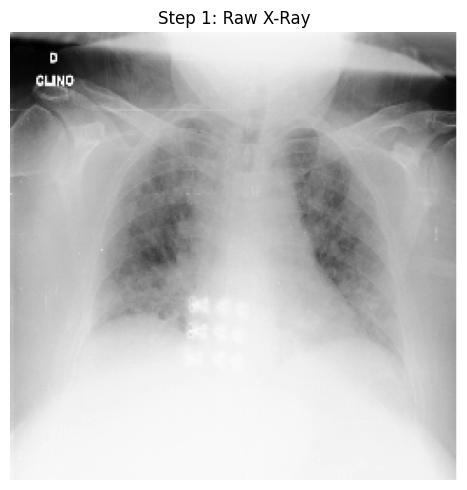

In [10]:
img_gray = cv2.imread(DATA_PATH, cv2.IMREAD_GRAYSCALE)
cv2.imwrite('output/01_raw_xray.png', img_gray)

plt.figure(figsize=(5, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('Step 1: Raw X-Ray', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 2: Histogram Equalization
Redistribute pixel intensities across the full 0-255 range.

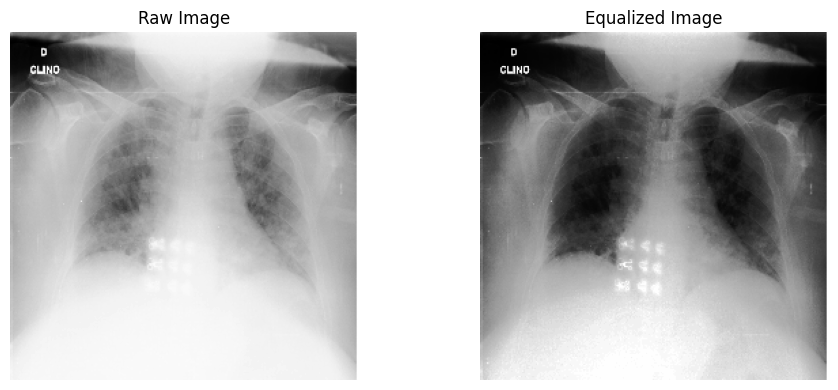

In [11]:
img_equalized = cv2.equalizeHist(img_gray)
cv2.imwrite('output/02_equalized_xray.png', img_equalized)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Raw Image')
axes[0].axis('off')
axes[1].imshow(img_equalized, cmap='gray')
axes[1].set_title('Equalized Image')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Step 3: JET Colormap
Map equalized grayscale intensities to a false-color heatmap.

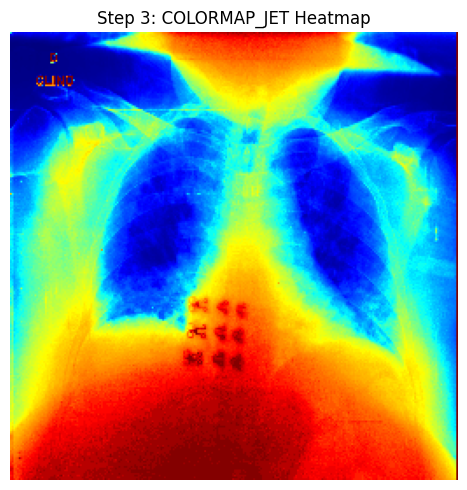

In [12]:
img_colormap = cv2.applyColorMap(img_equalized, cv2.COLORMAP_JET)
cv2.imwrite('output/03_colormap_jet_heatmap.png', img_colormap)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_colormap, cv2.COLOR_BGR2RGB))
plt.title('Step 3: COLORMAP_JET Heatmap', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 4: Color Balance
Apply per-channel gains ($R{\times}1.2$, $G{\times}0.95$, $B{\times}0.9$) to the heatmap.

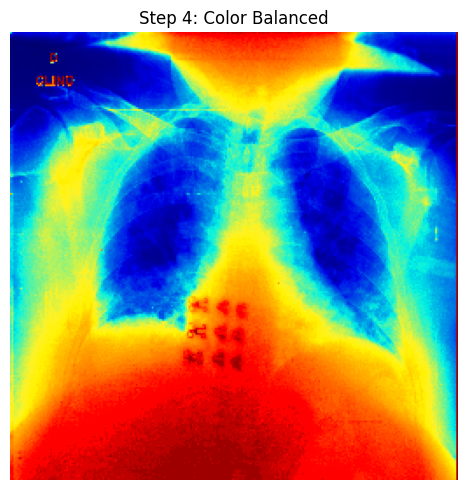

In [13]:
alpha_r, alpha_g, alpha_b = 1.2, 0.95, 0.9
b, g, r = cv2.split(img_colormap)

r_balanced = np.clip(r.astype(np.float32) * alpha_r, 0, 255).astype(np.uint8)
g_balanced = np.clip(g.astype(np.float32) * alpha_g, 0, 255).astype(np.uint8)
b_balanced = np.clip(b.astype(np.float32) * alpha_b, 0, 255).astype(np.uint8)

img_balanced = cv2.merge([b_balanced, g_balanced, r_balanced])
cv2.imwrite('output/04_color_balanced.png', img_balanced)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_balanced, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Color Balanced', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Dense Tissue Threshold
Binary threshold ($T \ge 200$) on the equalized image to isolate dense structures.

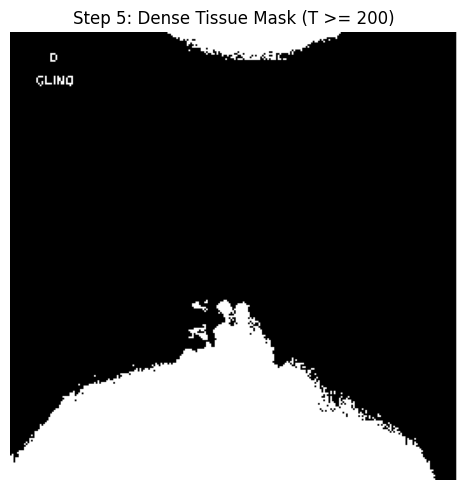

In [14]:
_, img_threshold = cv2.threshold(img_equalized, 200, 255, cv2.THRESH_BINARY)
cv2.imwrite('output/05_dense_tissue_threshold.png', img_threshold)

plt.figure(figsize=(5, 5))
plt.imshow(img_threshold, cmap='gray')
plt.title('Step 5: Dense Tissue Mask (T >= 200)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 6: Logarithmic Transform
Apply $s = c \cdot \ln(1 + r)$ to the raw image to expand dark regions.

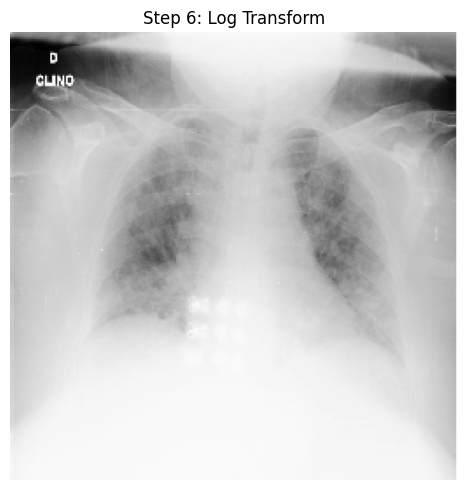

In [15]:
img_norm = img_gray.astype(np.float32) / 255.0
c = 255.0 / np.log(1.0 + 1.0)
img_log = np.clip(c * np.log(1.0 + img_norm), 0, 255).astype(np.uint8)

cv2.imwrite('output/06_logarithmic_transform.png', img_log)

plt.figure(figsize=(5, 5))
plt.imshow(img_log, cmap='gray')
plt.title('Step 6: Log Transform', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 7: Gamma Transform
Apply $s = c \cdot r^{\gamma}$ with $\gamma = 0.5$ to brighten midtones.

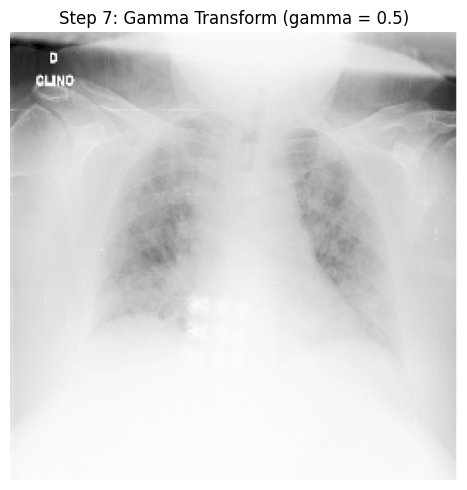

In [16]:
gamma = 0.5
img_gamma = np.clip(np.power(img_norm, gamma) * 255.0, 0, 255).astype(np.uint8)

cv2.imwrite('output/07_gamma_transform.png', img_gamma)

plt.figure(figsize=(5, 5))
plt.imshow(img_gamma, cmap='gray')
plt.title('Step 7: Gamma Transform (gamma = 0.5)', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

## Step 8: Comparison Dashboard
Side-by-side view of all 7 stages.

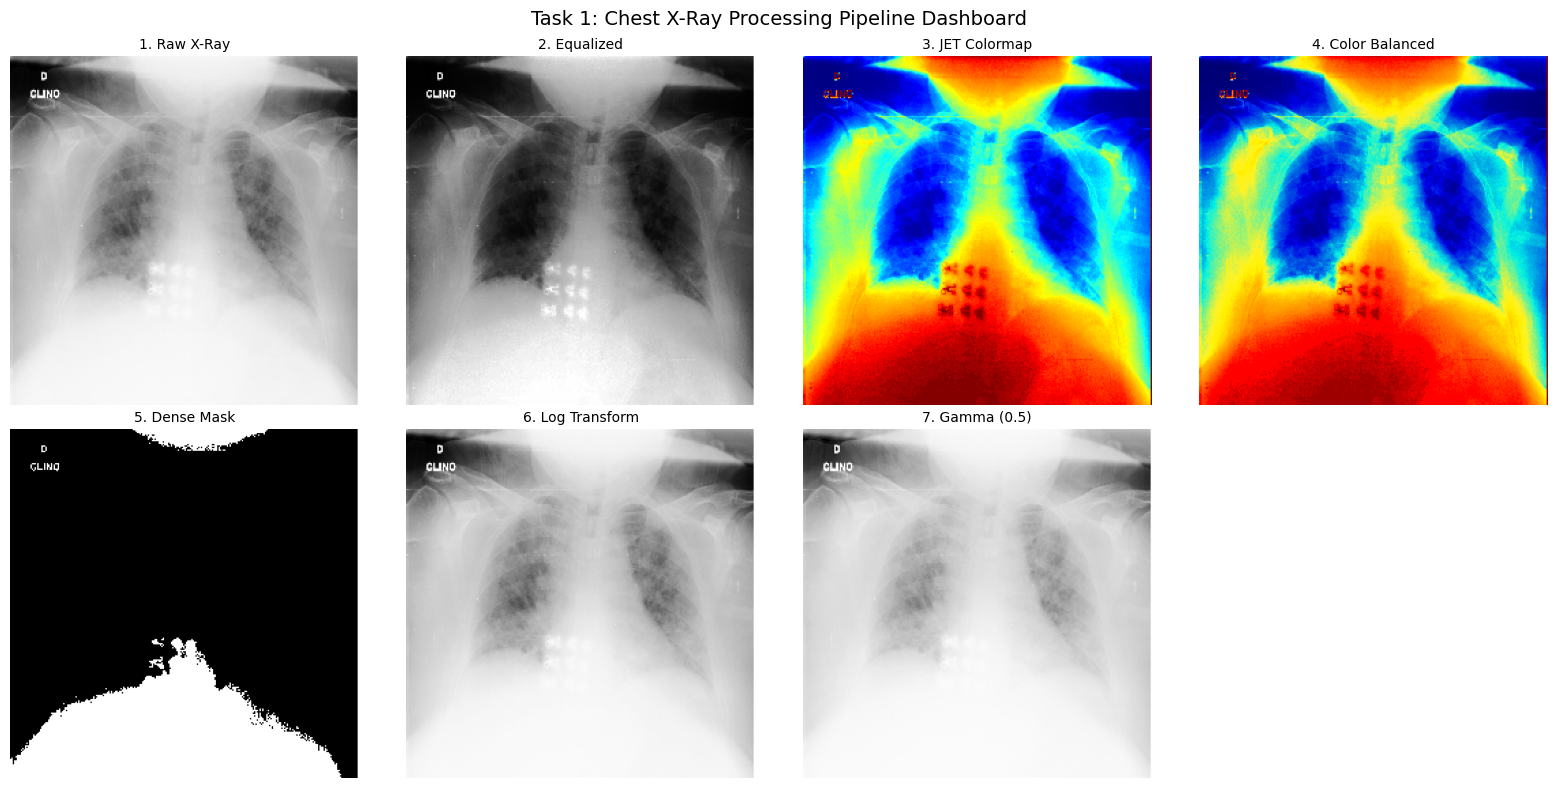

In [17]:
def to_rgb(img):
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

stages = [
    ('1. Raw X-Ray', img_gray),
    ('2. Equalized', img_equalized),
    ('3. JET Colormap', img_colormap),
    ('4. Color Balanced', img_balanced),
    ('5. Dense Mask', img_threshold),
    ('6. Log Transform', img_log),
    ('7. Gamma (0.5)', img_gamma)
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, (title, img) in enumerate(stages):
    axes[i].imshow(to_rgb(img))
    axes[i].set_title(title, fontsize=10)
    axes[i].axis('off')

axes[7].set_visible(False)

plt.suptitle('Task 1: Chest X-Ray Processing Pipeline Dashboard', fontsize=14, y=0.98)
plt.tight_layout()
plt.savefig('output/08_full_comparison_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()